Data analysis exercise using data from Anatel, a brazillian telecom state enterprise, to use python to generate insights and answe the following questions:

- How the number of total accesses evolved?
- Which states concentrate the most acceses?
- Which technologies are in decline and which dominate the market?
- Are there any inequalities in the regional access to mobile telephony?

In [ ]:
import pandas as pd

In [3]:
df = pd.read_csv("br_anatel_telefonia_movel_ddd.csv")

In [6]:
# Visualizing Statistics

#Structure
print(df.info())

#Stats
print(df.describe())

#Correlation
df.select_dtypes(include=['number']).corr()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 55043 entries, 0 to 55042
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   ano         55043 non-null  int64 
 1   mes         55043 non-null  int64 
 2   sigla_uf    55043 non-null  object
 3   ddd         55043 non-null  int64 
 4   tecnologia  55043 non-null  object
 5   sinal       55043 non-null  object
 6   acessos     55043 non-null  int64 
dtypes: int64(4), object(3)
memory usage: 2.9+ MB
None
                ano           mes           ddd       acessos
count  55043.000000  55043.000000  55043.000000  5.504300e+04
mean    2014.611813      6.474683     55.856203  6.449459e+05
std        3.402866      3.417317     27.050296  1.592912e+06
min     2009.000000      1.000000     11.000000  1.000000e+00
25%     2012.000000      4.000000     33.000000  1.053450e+04
50%     2015.000000      6.000000     55.000000  9.481900e+04
75%     2017.000000      9.000000     81.00

,ano,mes,ddd,acessos
ano,1.000000,-0.057021,0.004926,0.048314
mes,-0.057021,1.000000,0.001478,-0.004703
ddd,0.004926,0.001478,1.000000,-0.132687
acessos,0.048314,-0.004703,-0.132687,1.000000


Just a initial visualizing of the data to know what I'm dealing with

In [ ]:
# Data exploration

print(f"Years: {df["ano"].unique()}")
print(f"Months: {df["mes"].sort_values().unique()}")

print()

print(f"UFs: {df["sigla_uf"].unique()}")

print()

print(f"Tecnologias: {df["tecnologia"].unique()}")

print()

print(f"Sinais: {df["sinal"].sort_values().unique()}")


Years: [2009 2010 2011 2012 2013 2014 2015 2016 2017 2018 2019 2020 2021]
Meses: [ 1  2  3  4  5  6  7  8  9 10 11 12]

UFs: ['AC' 'AL' 'AM' 'AP' 'BA' 'CE' 'DF' 'ES' 'GO' 'MA' 'MG' 'MS' 'MT' 'PA'
 'PB' 'PE' 'PI' 'PR' 'RJ' 'RN' 'RO' 'RR' 'RS' 'SC' 'SE' 'SP' 'TO']

Tecnologias: ['CDMA IS 95' 'CDMA2000' 'Dados > 256kbps' 'Dados até 256kbps' 'GSM'
 'WCDMA' 'AMPS' 'TDMA' 'Dados' 'Dados Banda Larga' 'M2M' 'LTE'
 'M2M Padrão' 'M2M Especial']

Sinais: ['1G' '2G' '3G' '4G' 'M2M']


More data showcase, to continue understanding the data I'm dealing with

In [12]:
total_access = df["acessos"].sum()
print(f"Total accesses on the period: {total_access}")

total_per_year = df.groupby("ano")["acessos"].sum()
print(f"Total acceses per year: {total_per_year}")

Total accesses per period: 35499757839
Total acceses per year: ano
2009    1782073804
2010    2243930332
2011    2649833103
2012    3062038127
2013    3200421274
2014    3316019008
2015    3336560872
2016    3033841803
2017    2897380045
2018    2811642305
2019    2738887910
2020    2733486609
2021    1693642647
Name: acessos, dtype: int64


How the number of total accesses evolved?

As can be seen, the number of accesses demonstrated growth until 2015, after which it began to decline. This trend can be attributed to the decrease in the average number of chips per person.

In [14]:
pd.options.display.float_format = '{:.0f}'.format

# UF = federative units, another name for states
access_per_uf = (
    df.groupby("sigla_uf")
    ["acessos"].sum()
    .reset_index()
    .sort_values("acessos", ascending=False)
)

print(f"Biggest access per uf:\n{access_per_uf.head(10)}")
print()
print(f"Least access per uf:\n{access_per_uf.tail(10)}")

Biggest access per uf:
   sigla_uf     acessos
25       SP  9163735365
10       MG  3436914973
18       RJ  3132548939
4        BA  2230384263
17       PR  2110647460
22       RS  2074399842
15       PE  1557198327
5        CE  1375413375
8        GO  1123091133
13       PA  1122224908

Least access per uf:
   sigla_uf    acessos
2        AM  541390550
16       PI  488987256
11       MS  485216668
1        AL  484300128
24       SE  338789874
20       RO  289829078
26       TO  242809090
0        AC  117395671
3        AP  115079327
21       RR   70829741


In [18]:
# DDD is Brazil's system to link a phone number to the city or region it was created.
# A state can have multiple DDDs depending on it size

access_per_ddd = (
    df.groupby(["sigla_uf", "ddd"])["acessos"]
    .sum()
    .reset_index()
    .sort_values("acessos", ascending=False)
)

ger_total = access_per_ddd["acessos"].sum()
access_per_ddd["percentual_%"] = (access_per_ddd["acessos"] / ger_total) * 100

print(f"Total accesses per DDD:\n{access_per_ddd.head(10)}")


Total accesses per DDD:
   sigla_uf  ddd     acessos  percentual_%
60       SP   11  5050758349            14
46       RJ   21  2434784103             7
20       MG   31  1428746919             4
34       PE   81  1250437997             4
68       SP   19  1210281407             3
52       RS   51  1126168821             3
5        BA   71   881137701             2
10       CE   85   868082852             2
16       GO   62   829505123             2
12       DF   61   824234409             2


Which states concentrate the most acceses?

The southeast, south and most populous states are the ones that concentrate the most accesses

Are there any inequalities in the regional access to mobile telephony?

As observed, the states in the Southeast and South regions, Brazil's wealthiest regions, concentrate the majority of accesses. The exceptions, namely Bahia, Ceará, Pará, and Pernambuco, are highly populous states and represent the more developed areas of the North and Northeast. This explains why they appear high on the list, despite being part of Brazil's generally less affluent region. The Center-West region presents a complex and diverse picture because the wealth and population levels vary significantly depending on the specific state.

In [23]:
access_signal_year = (
    df.groupby(['ano','sinal'])["acessos"]
    .sum()
    .reset_index()
    .sort_values(["ano", "acessos"], ascending=[True,False])
)

print(f"Total accesses per year and signal:\n{access_signal_year}")

Total accesses per year and signal:
     ano sinal     acessos
1   2009    2G  1733954911
2   2009    3G    48055748
0   2009    1G       63145
4   2010    2G  2070329765
5   2010    3G   173591403
3   2010    1G        9164
6   2011    2G  2309987709
7   2011    3G   339845394
8   2012    2G  2389328455
9   2012    3G   628092173
10  2012   M2M    44617499
11  2013    2G  2144184965
12  2013    3G   959328084
14  2013   M2M    92393566
13  2013    4G     4514659
15  2014    2G  1632394109
16  2014    3G  1529520260
18  2014   M2M   109855242
17  2014    4G    44249397
20  2015    3G  1961528138
19  2015    2G  1065204242
21  2015    4G   178882810
22  2015   M2M   130945682
24  2016    3G  1697612566
23  2016    2G   682813877
25  2016    4G   510408983
26  2016   M2M   143006377
28  2017    3G  1260179077
29  2017    4G   996396263
27  2017    2G   473123923
30  2017   M2M   167680782
33  2018    4G  1423241478
32  2018    3G   848790734
31  2018    2G   332227110
34  2018   M2M   20

As the data is too extense I will plot graphs to help visualization

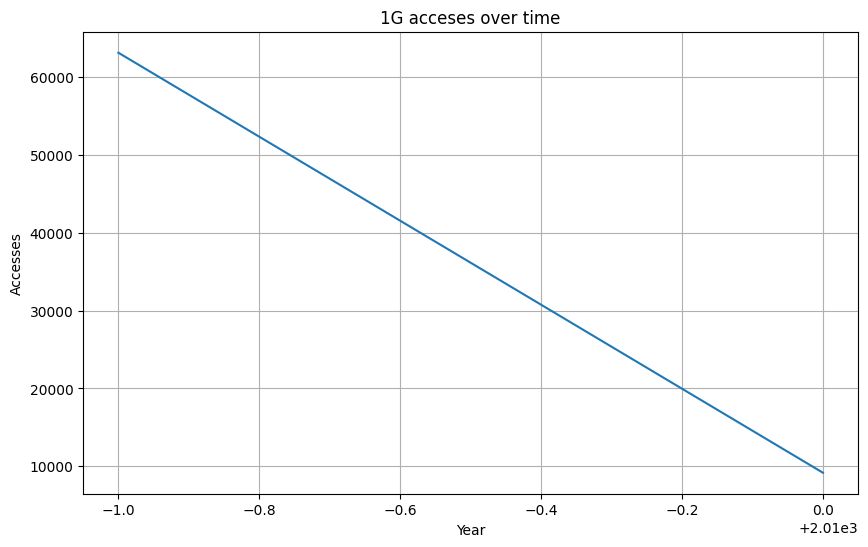

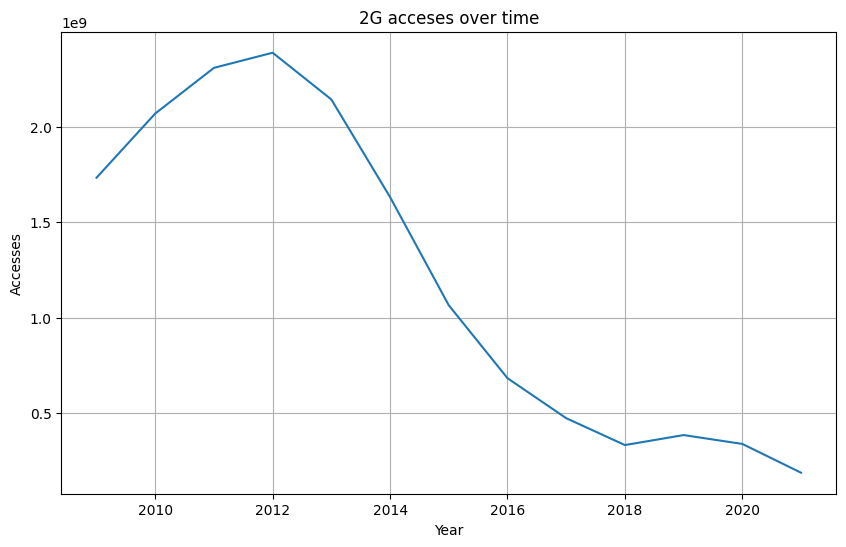

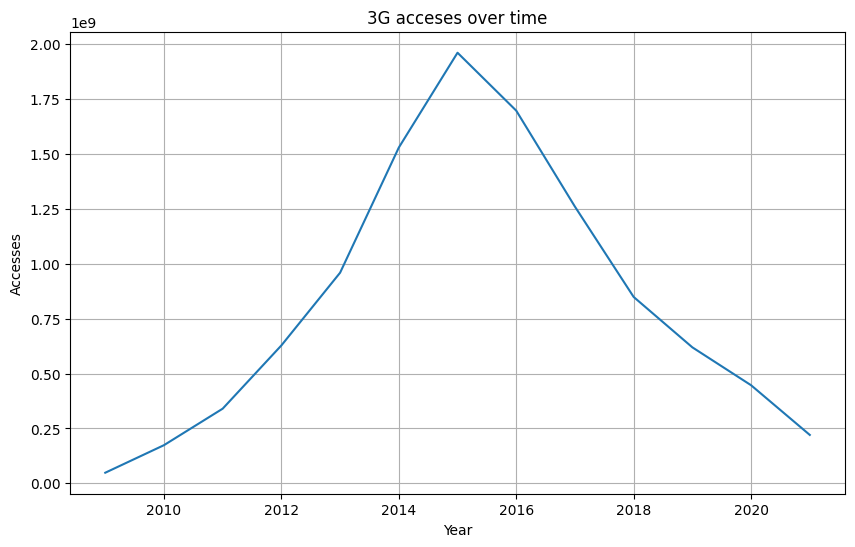

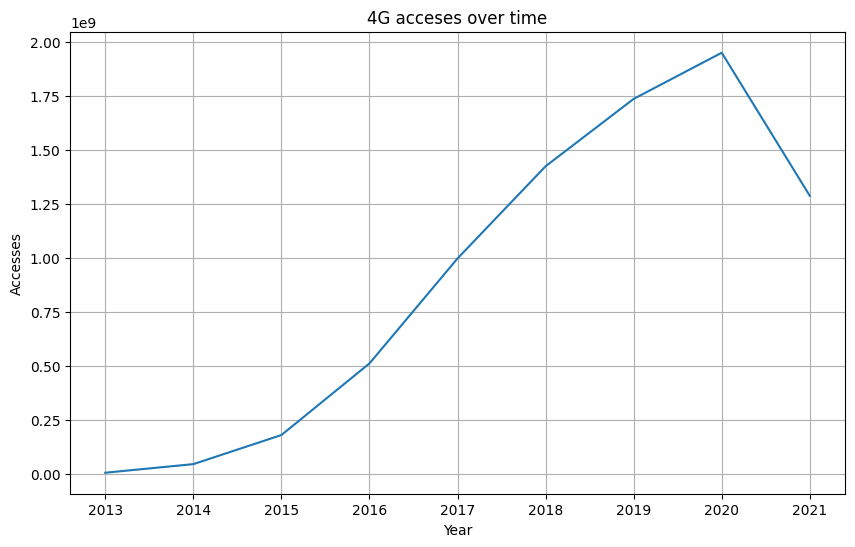

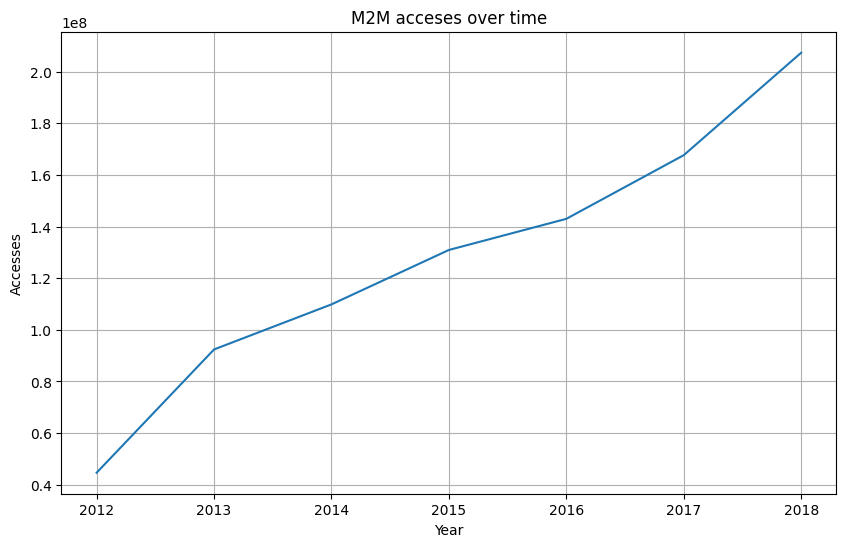

In [27]:
import matplotlib.pyplot as plt

signals = ["1G", "2G", "3G", "4G", "M2M"]

for label in signals:
  filtered_signal = access_signal_year[access_signal_year["sinal"] == label]
  plt.figure(figsize=(10, 6))
  plt.plot(filtered_signal["ano"], filtered_signal["acessos"])
  plt.title(f"{label} acceses over time")
  plt.xlabel("Year")
  plt.ylabel("Accesses")
  plt.grid(True)
  plt.show()

Which technologies are in decline and which dominate the market?

As the time passes the newer and more modern technologies dominate the market and the older ones become obsolete and suddently desapear as happened to 1G, right now 4G is already starting to decline and M2M is alreading taking the market